In [4]:
import kagglehub
import pandas as pd
import os
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "IMDB Dataset.csv"))

df.head()

['IMDB Dataset.csv']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


**preprocessing**

In [5]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [6]:
df.dropna(inplace=True)

In [7]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

In [8]:
def clean_text(text):
    text = text.lower()  # lowercase
    return text

df['review'] = df['review'].apply(clean_text)

In [9]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production. <br /><br />the...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically there's a family where a little boy ...,0
4,"petter mattei's ""love in the time of money"" is...",1


In [10]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    return text

df['review'] = df['review'].apply(clean_text)

**3.training**

In [11]:
from sklearn.model_selection import train_test_split
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review'],
    df['sentiment'],
    test_size=0.2,
    random_state=42
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42
)
print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))
print("Test size:", len(test_texts))

Train size: 40000
Validation size: 5000
Test size: 5000


**4.tokenization(BERT)**

In [12]:
!pip install transformers

In [13]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=256
)
print(train_encodings.keys())

dict_keys(['input_ids', 'token_type_ids', 'attention_mask'])


**5.pytorch dataset creation**

In [14]:
import torch

class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [15]:
train_dataset = IMDBDataset(train_encodings, train_labels)
val_dataset = IMDBDataset(val_encodings, val_labels)
test_dataset = IMDBDataset(test_encodings, test_labels)

In [16]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)
test_loader = DataLoader(test_dataset, batch_size=8)

In [17]:
batch = next(iter(train_loader))
print(batch.keys())

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])


**6.model training**

In [18]:
from transformers import AutoModelForSequenceClassification
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


cpu


In [19]:
from torch.optim import AdamW
optimizer = AdamW(model.parameters(), lr=2e-5)

**7.training loop**

In [32]:
df = df.sample(5000, random_state=42)
max_length=64
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

In [34]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW

df = df.sample(3000, random_state=42)

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=64)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=64)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=64)

class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()
    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.encodings['input_ids'][idx]),
            'attention_mask': torch.tensor(self.encodings['attention_mask'][idx]),
            'labels': torch.tensor(self.labels[idx])
        }
    def __len__(self):
        return len(self.labels)

train_dataset = IMDBDataset(train_encodings, train_labels)
val_dataset = IMDBDataset(val_encodings, val_labels)
test_dataset = IMDBDataset(test_encodings, test_labels)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)
test_loader = DataLoader(test_dataset, batch_size=4)

model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

model.train()
epochs = 2

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    total_loss = 0
    for i, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
        if i % 100 == 0:
            print(f"Batch {i}, Loss: {loss.item()}")
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} Training Loss: {avg_loss}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Epoch 1/2
Batch 0, Loss: 0.6552989482879639
Batch 100, Loss: 0.6581801772117615
Batch 200, Loss: 0.17283837497234344
Batch 300, Loss: 0.4332071840763092
Batch 400, Loss: 0.45140114426612854
Batch 500, Loss: 0.4576762616634369
Epoch 1 Training Loss: 0.5304000007112821

Epoch 2/2
Batch 0, Loss: 0.16586822271347046
Batch 100, Loss: 0.024090904742479324
Batch 200, Loss: 0.049034491181373596
Batch 300, Loss: 0.3378675878047943
Batch 400, Loss: 0.276880145072937
Batch 500, Loss: 0.12153194099664688
Epoch 2 Training Loss: 0.30777250581420956


In [35]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

model.eval()

preds = []
true = []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        preds.extend(predictions.cpu().numpy())
        true.extend(batch['labels'].cpu().numpy())

accuracy = accuracy_score(true, preds)
precision, recall, f1, _ = precision_recall_fscore_support(true, preds, average='binary')
cm = confusion_matrix(true, preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

Accuracy: 0.7433333333333333
Precision: 0.8416666666666667
Recall: 0.6352201257861635
F1 Score: 0.7240143369175627
Confusion Matrix:
 [[122  19]
 [ 58 101]]


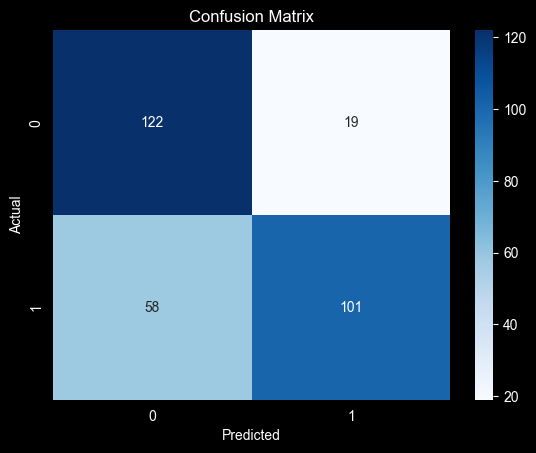

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

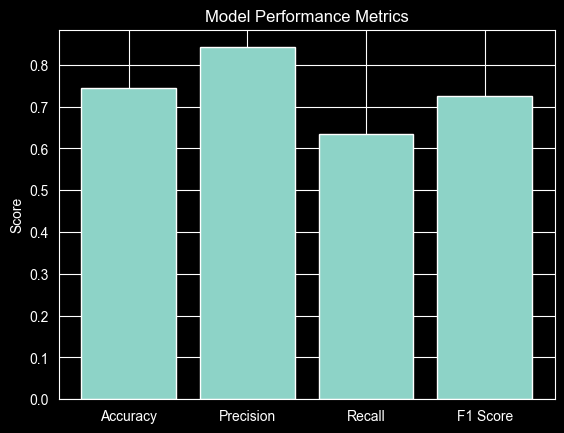

In [37]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

plt.bar(metrics.keys(), metrics.values())
plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.show()

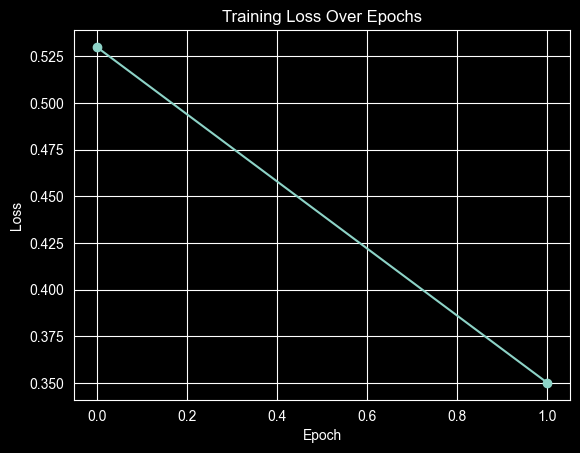

In [38]:
losses = [0.53, 0.35]  # example from your epochs

plt.plot(losses, marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()